# Arbeiten mit Daten in `pandas`

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/eistage.csv",
    sep=";",
    skiprows=2,
    nrows=70,
    usecols=[3,5,6],
    parse_dates=["year"],
    na_values=[1900, -999, -999],
    names=["year", "heat", "ice"],
    index_col=0
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/eistage.csv'

## Data Exploration

In [ ]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 70 entries, 1955-01-01 to 2024-01-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   heat    70 non-null     int64
 1   ice     70 non-null     int64
dtypes: int64(2)
memory usage: 1.6 KB


In [ ]:
df.head(2)

,heat,ice
year,,
1955-01-01,1,25
1956-01-01,3,46


In [ ]:
df_neu = df.tail(10)

In [ ]:
df_neu

,heat,ice
year,,
2015-01-01,42,2
2016-01-01,20,13
2017-01-01,38,21
2018-01-01,37,13
2019-01-01,38,3
2020-01-01,21,3
2021-01-01,24,7
2022-01-01,31,6
2023-01-01,32,2


In [ ]:
df.head(10).tail(3).head(1)

,heat,ice
year,,
1962-01-01,14,25


In [ ]:
df.describe()

,heat,ice
count,70.000000,70.000000
mean,15.371429,20.414286
std,11.007470,12.062029
min,0.000000,2.000000
25%,6.500000,12.250000
50%,13.000000,19.500000
75%,21.000000,25.000000
max,45.000000,63.000000


## Daten Manipulieren (Projection)

In [ ]:
df["heat"]

year
1955-01-01     1
1956-01-01     3
1957-01-01    10
1958-01-01     9
1959-01-01     5
              ..
2020-01-01    21
2021-01-01    24
2022-01-01    31
2023-01-01    32
2024-01-01    45
Name: heat, Length: 70, dtype: int64

In [ ]:
df[ ["heat", "ice"] ]

,heat,ice
year,,
1955-01-01,1,25
1956-01-01,3,46
1957-01-01,10,20
1958-01-01,9,11
1959-01-01,5,17
...,...,...
2020-01-01,21,3
2021-01-01,24,7
2022-01-01,31,6


## Daten Manipulieren (Restriction)

In [ ]:
df.loc[ df["heat"] > 10 ].loc[ df["ice"] < 5 ]

,heat,ice
year,,
1974-01-01,11,3
2015-01-01,42,2
2019-01-01,38,3
2020-01-01,21,3
2023-01-01,32,2
2024-01-01,45,2


In [ ]:
df.iloc[0]

heat     1
ice     25
Name: 1955-01-01 00:00:00, dtype: int64

## Plotting in Python

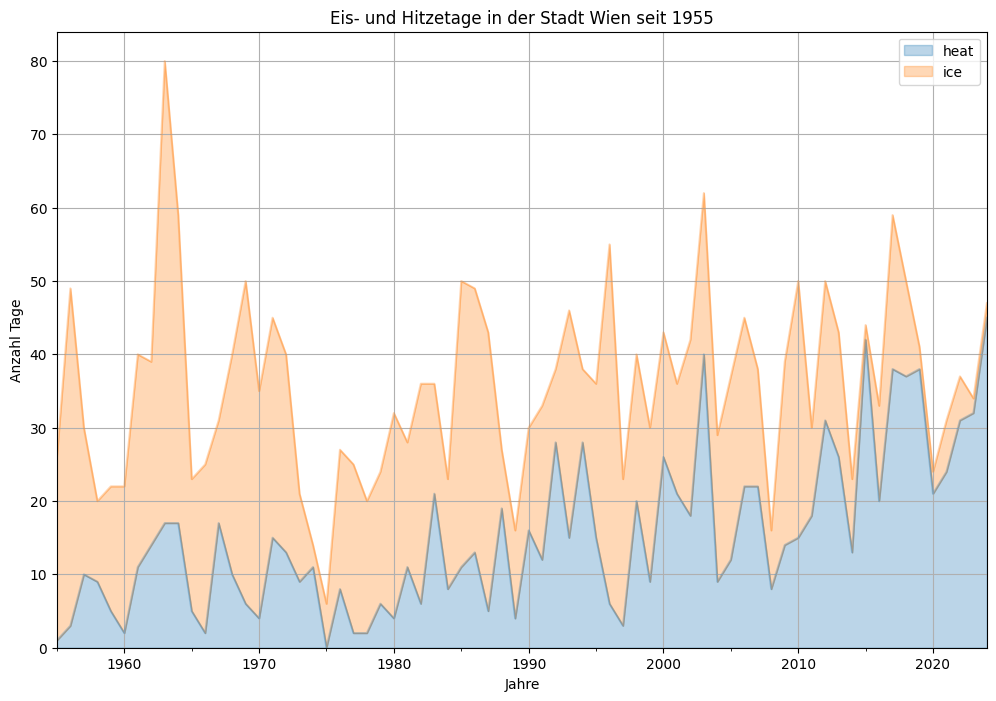

In [ ]:
df.plot(
    kind="area",
    figsize=(12,8),
    alpha=0.3
)
plt.xlabel("Jahre")
plt.ylabel("Anzahl Tage")
plt.title("Eis- und Hitzetage in der Stadt Wien seit 1955")
plt.grid(True)
plt.savefig("../output/eistage.png")

<Axes: xlabel='heat', ylabel='ice'>

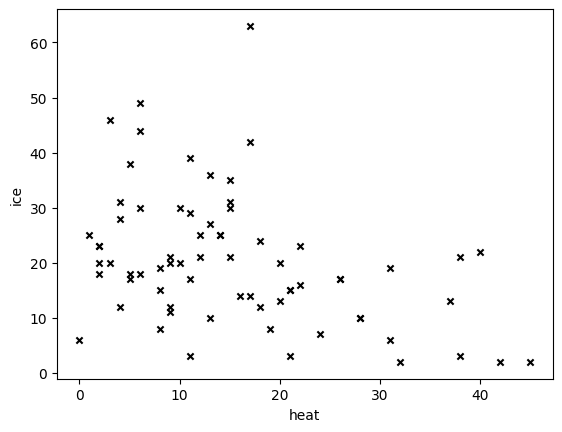

In [ ]:
df.plot(
    kind="scatter",
    x="heat",
    y="ice",
    marker="x",
    color="k"
)

<Axes: ylabel='Frequency'>

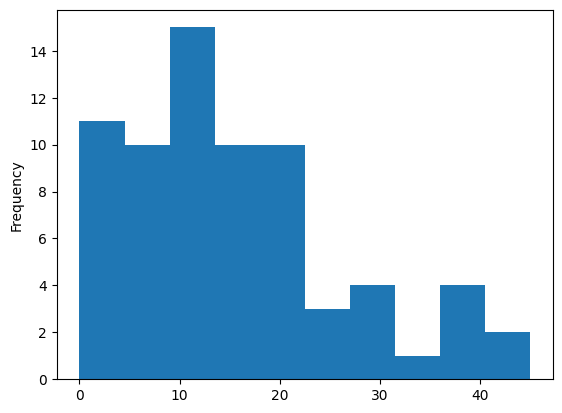

In [ ]:
df["heat"].plot(kind="hist")

<Axes: >

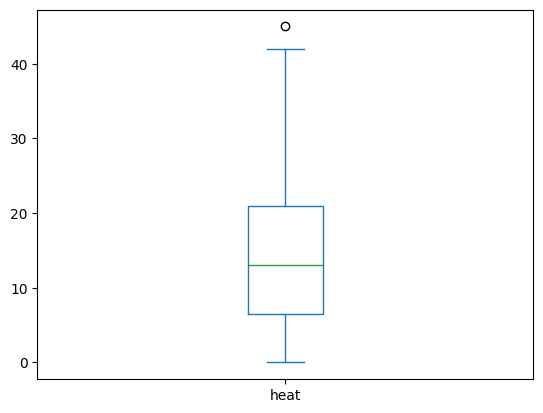

In [ ]:
df["heat"].plot(kind="box")

<Axes: xlabel='year'>

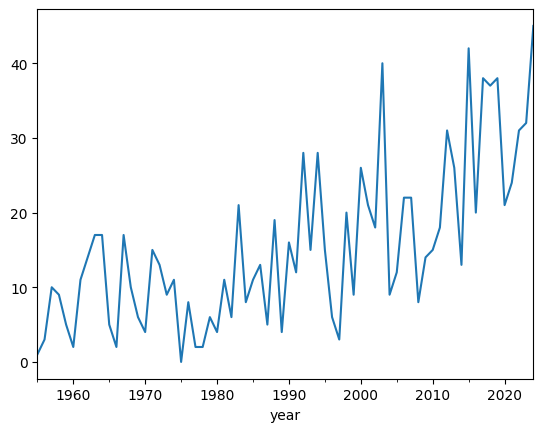

In [ ]:
df["heat"].plot()

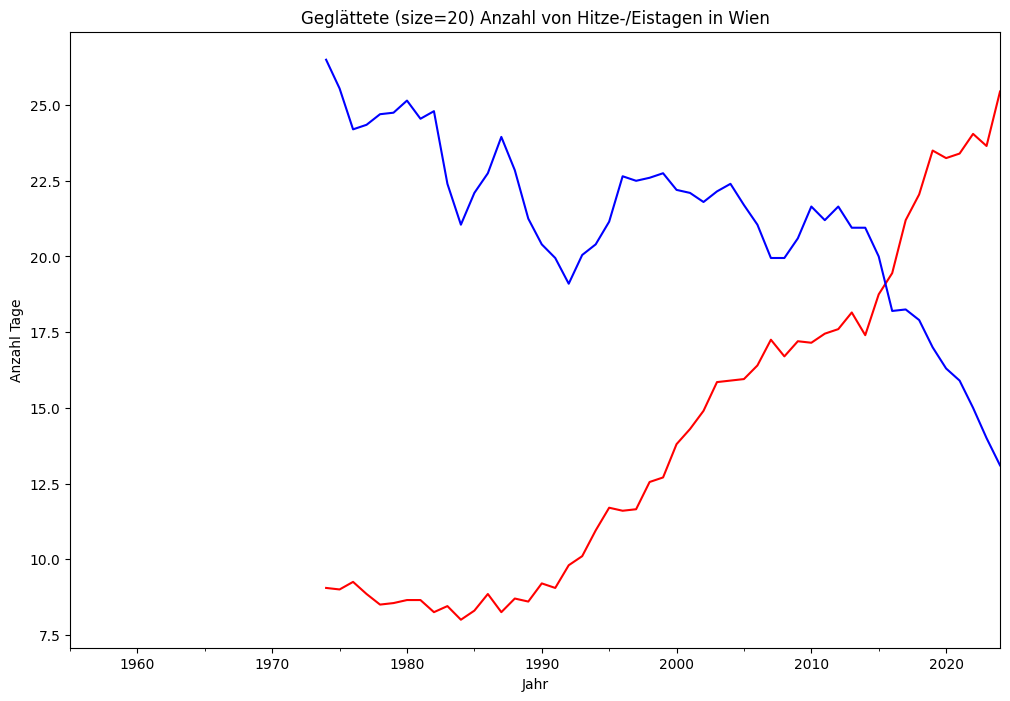

In [ ]:
df["heat"].rolling(20).mean().plot(figsize=(12,8), color="red")
df["ice"].rolling(20).mean().plot(figsize=(12,8), color="blue")
plt.title("Geglättete (size=20) Anzahl von Hitze-/Eistagen in Wien")
plt.ylabel("Anzahl Tage")
plt.xlabel("Jahr")
plt.savefig("../output/eistage_smooth.png")